In [ ]:
!pip install qiskit[visualization]
!pip install qiskit-aer
!pip install qiskit-ibm-runtime
!pip install pylatexenc

In [ ]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector
import qiskit.quantum_info as qi
from qiskit.visualization import plot_histogram

### Circuito con entrelazamiento y compuerta de fase

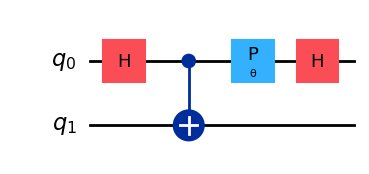

In [ ]:
# Circuito cuantico
parametro = Parameter('θ')
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.p(parametro, 0)
qc.h(0)
qc.draw('mpl')

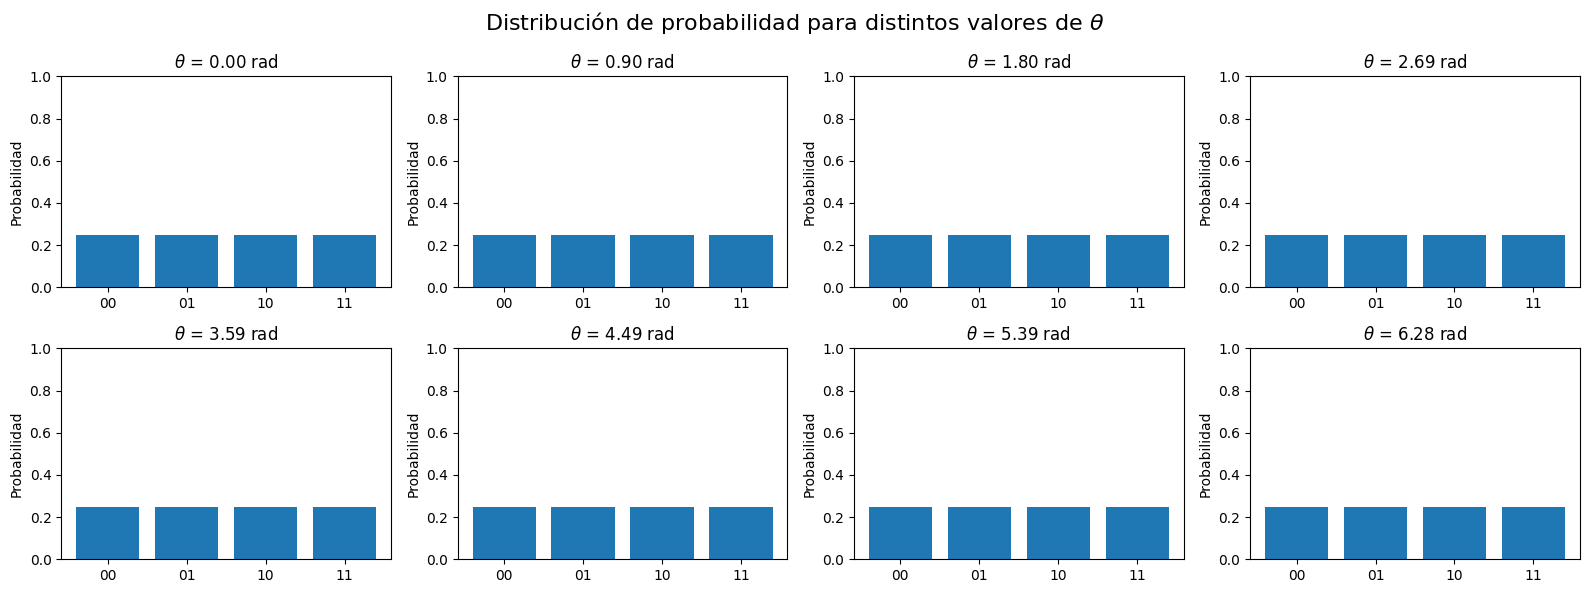

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

# Lista de valores de theta (en radianes)
theta_values = np.linspace(0, 2*np.pi, 8)

# Estados base para mostrar las probabilidades
basis_states = ['00', '01', '10', '11']

# Crear figura
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

# Recorremos distintos valores de theta
for idx, theta in enumerate(theta_values):
    # Crear circuito para |\psi_3⟩ = (I ⊗ I)|00⟩ + (I ⊗ P(θ))|01⟩
    qc = QuantumCircuit(2)
    qc.h(0)
    qc.cx(0, 1)
    qc.p(theta, 1)
    qc.h(0)

    # Obtener el vector de estado
    state = Statevector.from_instruction(qc)
    probs = state.probabilities_dict()

    # Extraer en orden canónico
    prob_list = [probs.get(bs, 0) for bs in basis_states]

    # Graficar
    axes[idx].bar(basis_states, prob_list)
    axes[idx].set_ylim(0, 1)
    axes[idx].set_title(f"$\\theta$ = {theta:.2f} rad")
    axes[idx].set_ylabel("Probabilidad")

plt.suptitle("Distribución de probabilidad para distintos valores de $\\theta$", fontsize=16)
plt.tight_layout()
plt.show()

## Circuito con entrelazamiento "imperfecto"

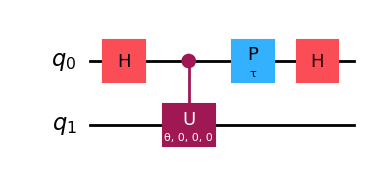

In [ ]:
theta = Parameter('θ')
# phi = Parameter('φ')
phi = 0
# lambda_p = Parameter('λ')
lambda_p = 0
tau = Parameter('τ')
qc = QuantumCircuit(2)
gamma = 0
qc.h(0)
qc.cu(theta, phi, lambda_p, gamma, 0, 1)
# qc.cp(gamma, 0, 1)
qc.p(tau, 0)
qc.h(0)
qc.draw('mpl')

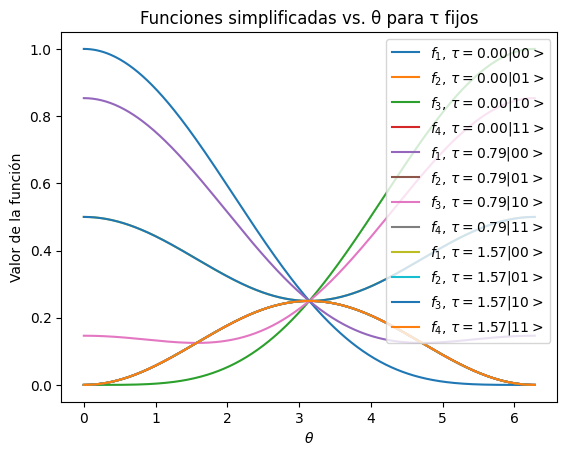

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define theta range and fixed tau values
theta = np.linspace(0, 2 * np.pi, 400)
taus = [0, np.pi/4, np.pi/2]

# Define the four functions
def f1(th, ta):
    return 1/4 + 1/2 * np.cos(th/2) * np.cos(ta) + 1/4*np.cos(th/2)**2

def f2(th, ta):
    return 1/4*np.sin(th/2)**2

def f3(th, ta):
    return 1/4 - 1/2 * np.cos(th/2) * np.cos(ta) + 1/4*np.cos(th/2)**2

def f4(th, ta):
    return 1/4*np.sin(th/2)**2

# Plot each function for each tau
plt.figure()
for tau in taus:
    plt.plot(theta, f1(theta, tau), label=fr'$f_1,\,\tau={tau:.2f} |00>$')
    plt.plot(theta, f2(theta, tau), label=fr'$f_2,\,\tau={tau:.2f} |01>$')
    plt.plot(theta, f3(theta, tau), label=fr'$f_3,\,\tau={tau:.2f} |10>$')
    plt.plot(theta, f4(theta, tau), label=fr'$f_4,\,\tau={tau:.2f} |11>$')

plt.xlabel(r'$\theta$')
plt.ylabel('Valor de la función')
plt.title('Funciones simplificadas vs. θ para τ fijos')
plt.legend()
plt.show()

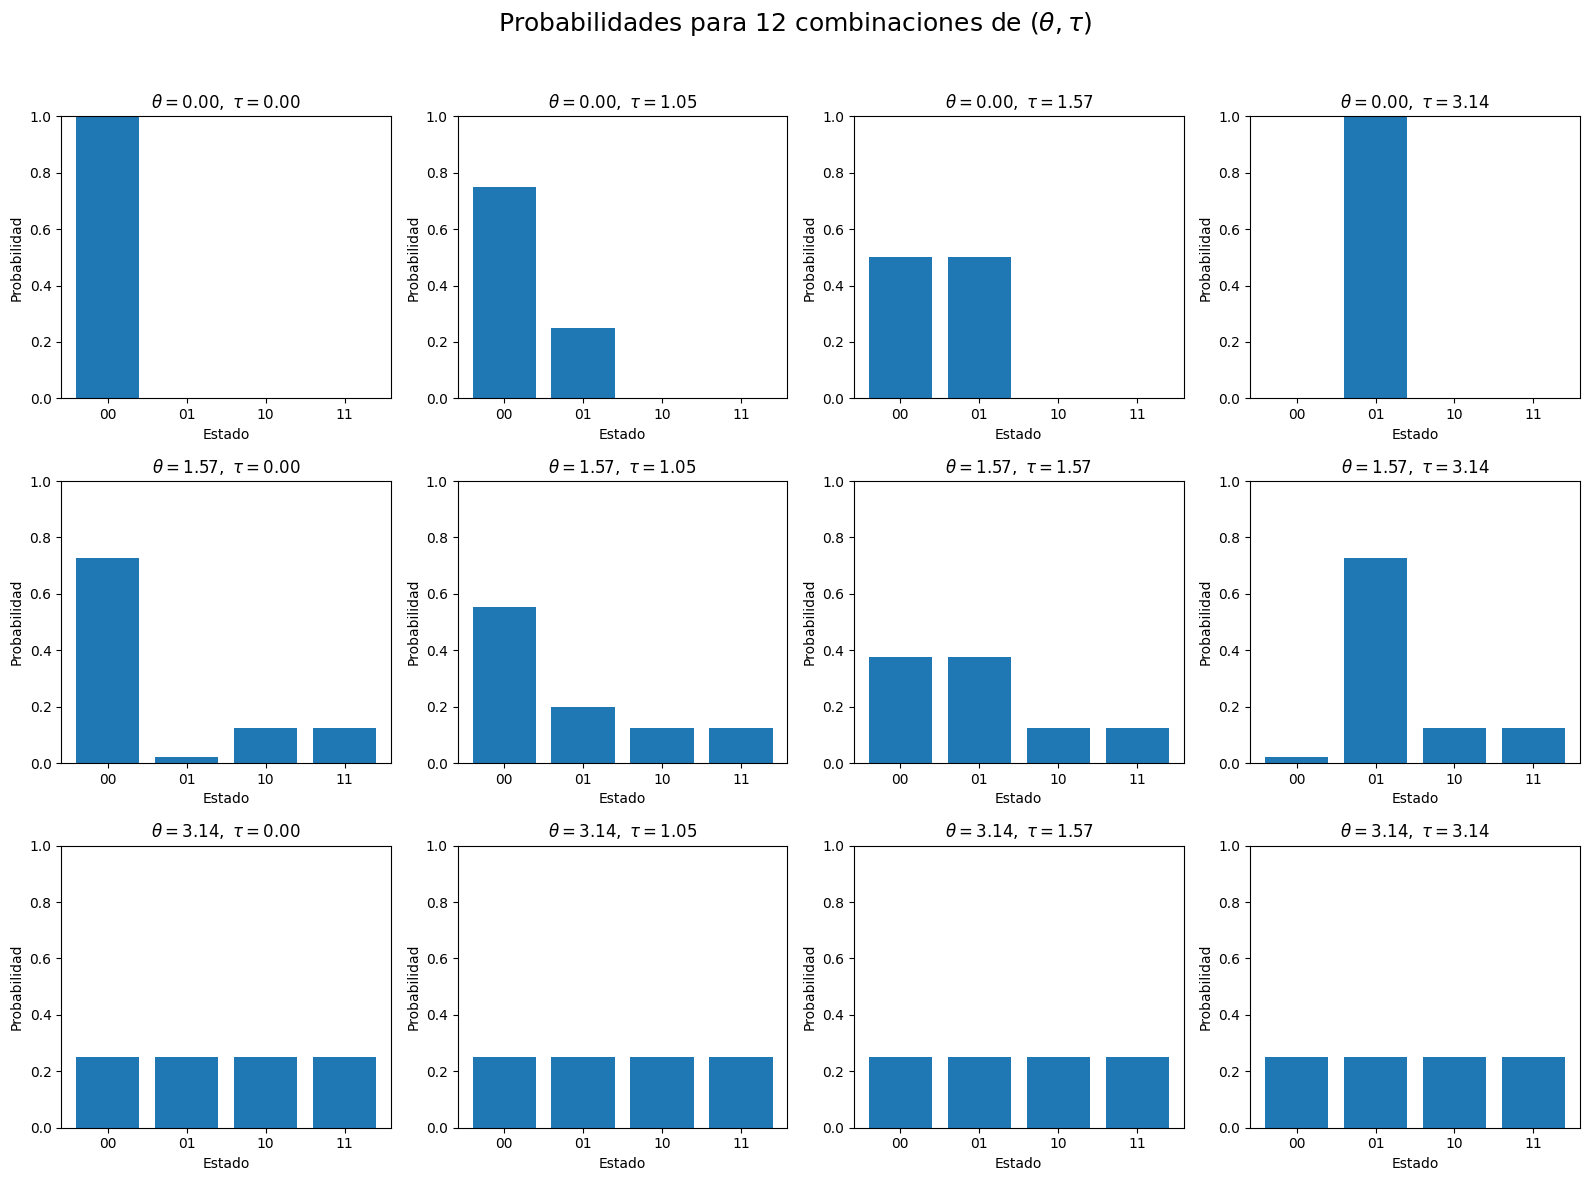

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

# --- 1) Definir los valores fijos de θ y τ ---
theta_list = [0, np.pi/2, np.pi]
tau_list   = [0, np.pi/3, np.pi/2, np.pi]

# Construyo la lista de pares (θ, τ)
pairs = [(theta, tau) for theta in theta_list for tau in tau_list]
# pairs tendrá longitud 3*4 = 12

# --- 2) Crear figura con 3 filas y 4 columnas ---
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

basis_states = ['00','01','10','11']
# Parámetros fijos de tu CU
phi      = 0
lambda_p = 0
gamma    = 0

# --- 3) Bucle sobre cada par (θ, τ) ---
for idx, (theta, tau) in enumerate(pairs):
    qc = QuantumCircuit(2)
    qc.h(0)
    # aplico CU(θ, φ, λ, γ) controlado 0→1
    qc.cu(theta, phi, lambda_p, gamma, 0, 1)
    # fase τ en el qubit 0
    qc.p(tau, 0)
    qc.h(0)

    st = Statevector.from_instruction(qc)
    probs = st.probabilities_dict()
    prob_list = [probs.get(bs, 0) for bs in basis_states]

    ax = axes[idx]
    ax.bar(basis_states, prob_list)
    ax.set_ylim(0,1)
    ax.set_title(r"$\theta={:.2f},\ \tau={:.2f}$".format(theta, tau))
    ax.set_ylabel("Probabilidad")
    ax.set_xlabel("Estado")

# Ajustes finales
plt.suptitle("Probabilidades para 12 combinaciones de $(\\theta,\\tau)$", fontsize=18)
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()